In [1]:
import logging

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import mannwhitneyu, spearmanr

import scarf
from scarf import cytebase
from scarf.plotting import CategoricalScale, CellField, NormalizationSpec

scarf.configure_output(level="WARNING", progress=False)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
pd.set_option("display.width", 160)

catalog = cytebase.Catalog()  # Public Cytebase unless CYTEBASE_BUCKET is set.

In [2]:
matches = catalog.search("wilk sars cov 2", ready_only=True, max_cell_chars=None)
match_preview = matches.to_markdown(
    columns=["cytebase_id", "title", "cell_count"], max_cell_chars=32
)
display(Markdown(match_preview))

if not matches:
    raise RuntimeError("The Wilk COVID-19 dataset is not ready in this catalog")
dataset_id = matches[0]["cytebase_id"]
entry = catalog.dataset(dataset_id)
entry

| Cytebase ID | Title | Cells |
| --- | --- | ---: |
| wilk&#95;2020&#95;single&#95;cell&#95;atlas&#95;per… | Single-cell atlas of peripheral… | 44,721 |

1 row. Long cells are shortened; use `max_cell_chars=None` to display complete values. Row dictionaries retain the full values.

### Single-cell atlas of peripheral immune response to SARS-CoV-2 infection

- **Cytebase ID:** `wilk_2020_single_cell_atlas_peripheral_sars_cov_2_infection_456e8b9b`
- **Citation:**
    - Publication: https://doi.org/10.1038/s41591-020-0944-y
    - Dataset Version: https://datasets.cellxgene.cziscience.com/8d7fad46-2f37-4aa0-ac9d-babbc36efb6f.h5ad
    - curated and distributed by CZ CELLxGENE Discover in Collection: https://cellxgene.cziscience.com/collections/a72afd53-ab92-4511-88da-252fb0e26b9a
- **DOI:** 10.1038/s41591-020-0944-y
- **CELLxGENE:** https://cellxgene.cziscience.com/collections/a72afd53-ab92-4511-88da-252fb0e26b9a
- **Explorer:** https://cellxgene.cziscience.com/e/456e8b9b-f872-488b-871d-94534090a865.cxg/
- **Size:** 44,721 cells, 24,505 genes
- **Status:** ready
- **Organisms:** Homo sapiens
- **Assays:** Seq-Well
- **Tissues:** blood
- **Diseases:** COVID-19, normal
- **Suspension:** cell
- **Source embeddings:** X_pca, X_umap

In [3]:
ds = catalog.open_datastore(entry.id)
print(ds)
print("\nImported embeddings:", sorted(cytebase.embeddings(ds)))
umap_ref = cytebase.embedding(ds, "X_umap")

DataStore has 44721 (44721) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'Admission', 'DPS', 
            'DTF', 'HLA1', 'IFN1', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'Ventilated', 'assay', 'assay_ontology_term_id', 
            'cell.type.coarse', 'cell.type.fine', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 
            'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 
            'nCount_RNA', 'nCount_SCT', 'nFeature_RNA', 'nFeature_SCT', 'observation_joinid', 
            'percent.mt', 'percent.rpl', 'percent.rps', 'percent.rrna', 'self_reported_ethnicity', 
            'self_reported_ethnicity_ontology_term_id', 'seurat_clusters', 'sex', 'sex_ontology_term_id', 'singler', 
            'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type'
   RNA assay has 24505 features and following metadata:
            'I', 'id


Imported embeddings: ['X_umap']


In [4]:
columns = [
    "cell_type",
    "cell.type.coarse",
    "disease",
    "donor_id",
    "Ventilated",
    "Admission",
    "DPS",
    "sex",
    "development_stage",
    "IFN1",
]
meta = ds.cells.to_pandas_dataframe(["ids", *columns], key="I").set_index("ids")
print(f"{len(meta):,} cells, {meta.shape[1]} metadata columns read")

44,721 cells, 10 metadata columns read


In [5]:
def distinct(values):
    return " / ".join(map(str, sorted(values.unique())))


donors = meta.groupby("donor_id").agg(
    disease=("disease", "first"),
    ventilated=("Ventilated", distinct),
    admission=("Admission", distinct),
    days_post_symptoms=("DPS", distinct),
    sex=("sex", "first"),
    age=("development_stage", "first"),
    cells=("disease", "size"),
)
donors

,disease,ventilated,admission,days_post_symptoms,sex,age,cells
donor_id,,,,,,,
C1,COVID-19,NonVent / Vent,ICU,9 / 11,male,seventh decade stage,8362
C2,COVID-19,NonVent,ICU,16,male,fifth decade stage,1735
C3,COVID-19,Vent,ICU,9,male,fourth decade stage,6545
C4,COVID-19,Vent,ICU,9,male,fourth decade stage,3688
C5,COVID-19,NonVent,ICU,15,male,sixth decade stage,2507
C6,COVID-19,Vent,ICU,2,male,80 year-old and over stage,1893
C7,COVID-19,NonVent,Floor,12,male,third decade stage,3364
H1,normal,Healthy,N/A,0,female,49-year-old stage,2100
H2,normal,Healthy,N/A,0,male,49-year-old stage,1941


In [6]:
by_type = pd.crosstab(meta["cell_type"], meta["disease"])
coarse_labels = meta.groupby("cell_type")["cell.type.coarse"].first()
by_type.insert(0, "coarse label", coarse_labels)
by_type.sort_values(["coarse label", "COVID-19"], ascending=[True, False])

disease,coarse label,COVID-19,normal
cell_type,,,
B cell,B,1715,1966
class switched memory B cell,B,1313,28
CD14-positive monocyte,CD14 Monocyte,8285,2054
monocyte,CD16 Monocyte,433,915
"CD4-positive, alpha-beta memory T cell",CD4 T,2890,1208
naive T cell,CD4 T,2224,1616
"CD4-positive, alpha-beta T cell",CD4 T,448,11
"CD8-positive, alpha-beta memory T cell",CD8 T,3312,2753
"effector CD8-positive, alpha-beta T cell",CD8 T,565,132


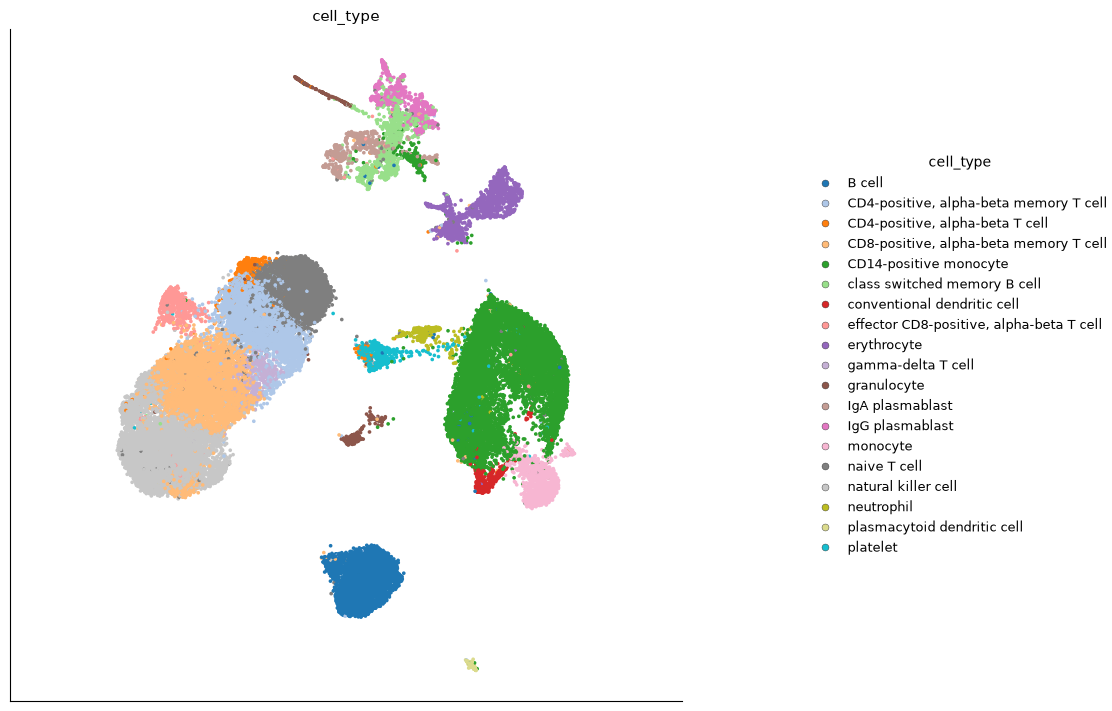

In [7]:
ds.plots.embedding(
    layout=umap_ref,
    color_by="cell_type",
    legend_loc="right",
    figsize=(12, 7),
)

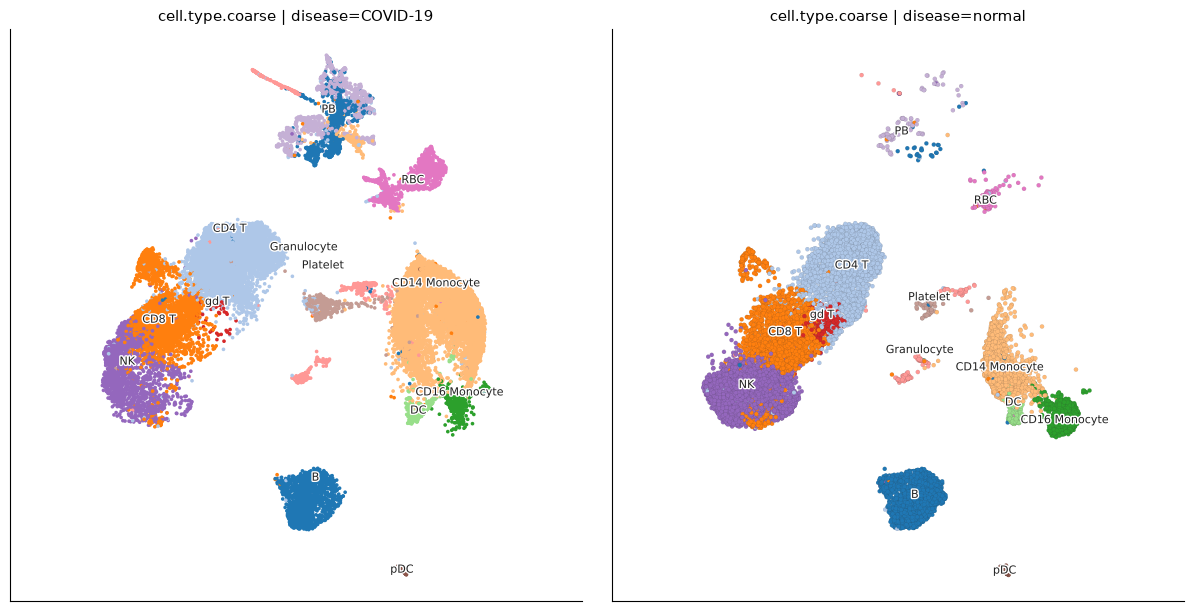

In [8]:
ds.plots.embedding(
    layout=umap_ref,
    color_by="cell.type.coarse",
    facet_by="disease",
    figsize=(12, 6),
)

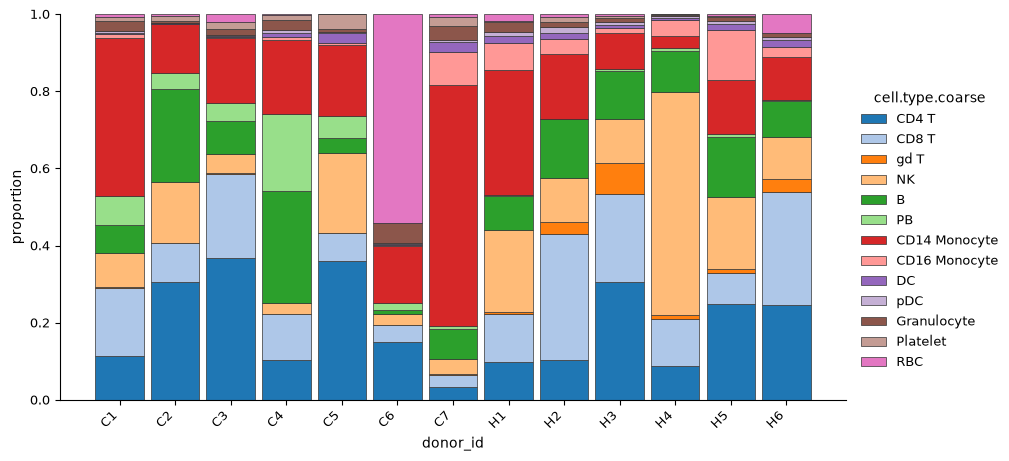

In [9]:
coarse_order = [
    "CD4 T",
    "CD8 T",
    "gd T",
    "NK",
    "B",
    "PB",
    "CD14 Monocyte",
    "CD16 Monocyte",
    "DC",
    "pDC",
    "Granulocyte",
    "Platelet",
    "RBC",
]
coarse_scale = CategoricalScale(order=tuple(coarse_order))

ds.plots.composition(
    category_by="cell.type.coarse",
    sample_by="donor_id",
    kind="stacked",
    categorical_scale=coarse_scale,
    figsize=(10, 4.5),
)

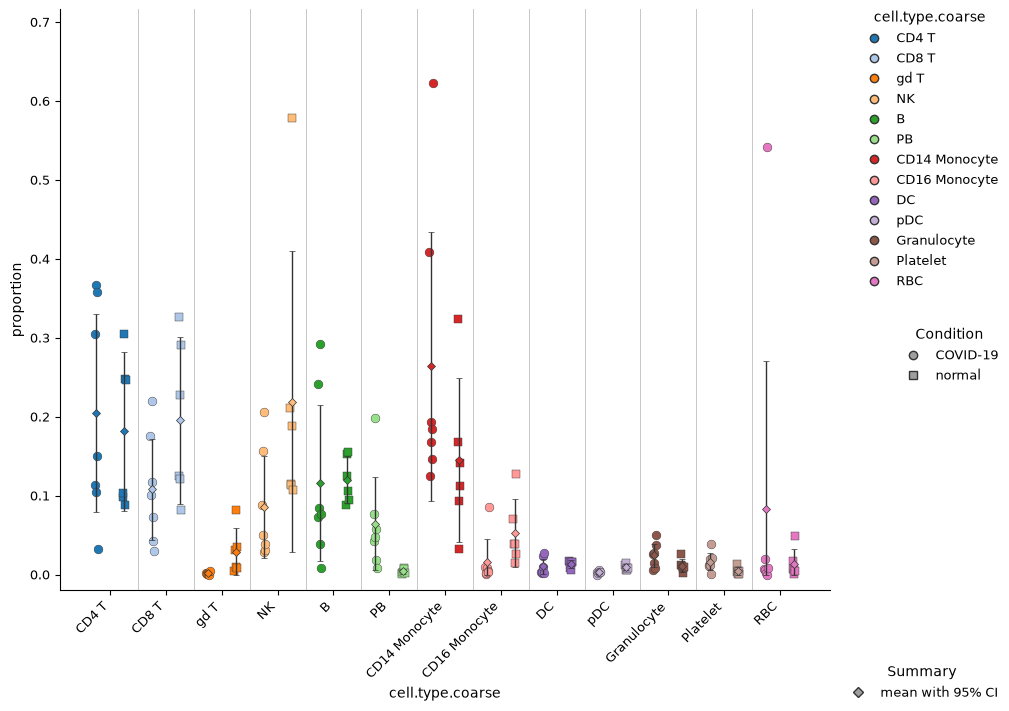

In [10]:
ds.plots.composition(
    category_by="cell.type.coarse",
    sample_by="donor_id",
    condition_by="disease",
    kind="per_sample",
    categorical_scale=coarse_scale,
    figsize=(10, 7),
    max_figure_width=None,
)

In [11]:
fractions = pd.crosstab(
    meta["donor_id"], meta["cell.type.coarse"], normalize="index"
)
shown = ["PB", "CD16 Monocyte", "gd T", "pDC", "NK", "RBC"]
fraction_table = fractions[shown].join(donors["disease"])
fraction_table.groupby("disease")[shown].agg(["min", "median", "max"]).T.round(3)

disease               COVID-19  normal
PB            min        0.009   0.001
              median     0.048   0.003
              max        0.199   0.008
CD16 Monocyte min        0.001   0.014
              median     0.005   0.039
              max        0.086   0.128
gd T          min        0.000   0.005
              median     0.001   0.020
              max        0.004   0.082
pDC           min        0.000   0.006
              median     0.003   0.008
              max        0.006   0.015
NK            min        0.028   0.108
              median     0.050   0.151
              max        0.207   0.579
RBC           min        0.000   0.001
              median     0.007   0.007
              max        0.542   0.049

In [12]:
marker_sets = {
    "T": ["CD3E", "IL7R", "CD8A"],
    "gd T": ["TRDC"],
    "NK": ["NKG7", "GNLY"],
    "B": ["MS4A1"],
    "PB": ["MZB1", "JCHAIN"],
    "Mono": ["CD14", "LYZ", "FCGR3A"],
    "DC": ["FCER1A"],
    "pDC": ["LILRA4"],
    "Gran.": ["CSF3R"],
    "Plt": ["PPBP"],
    "RBC": ["HBB"],
}
isg_genes = ["IFI27", "ISG15", "IFI44L", "IFI6"]

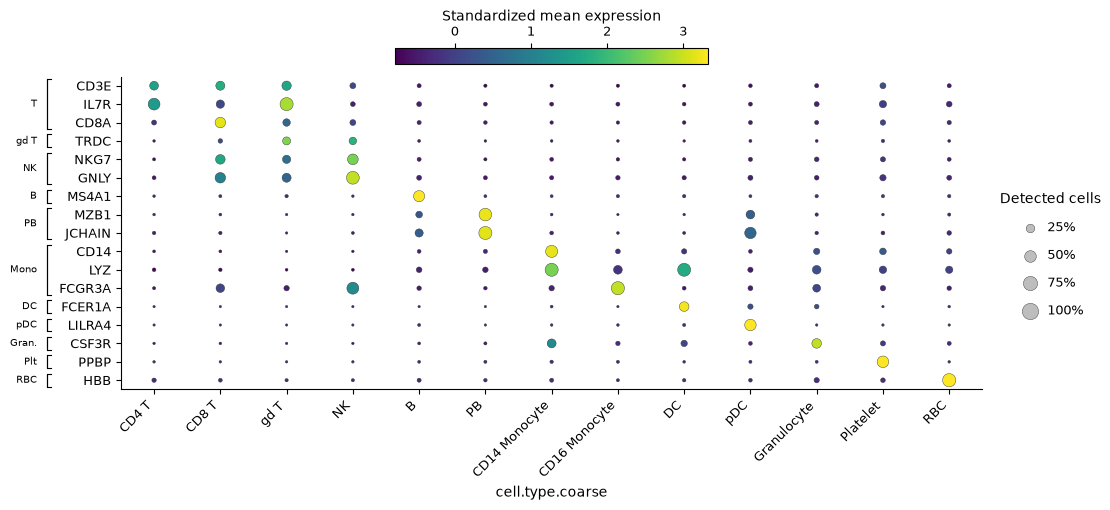

In [13]:
ds.plots.dotplot(
    features=marker_sets,
    group_by="cell.type.coarse",
    group_order=coarse_order,
    normalization=NormalizationSpec(transform="log1p"),
    standardize="feature",
    figsize=(11, 5),
    max_figure_width=None,
)

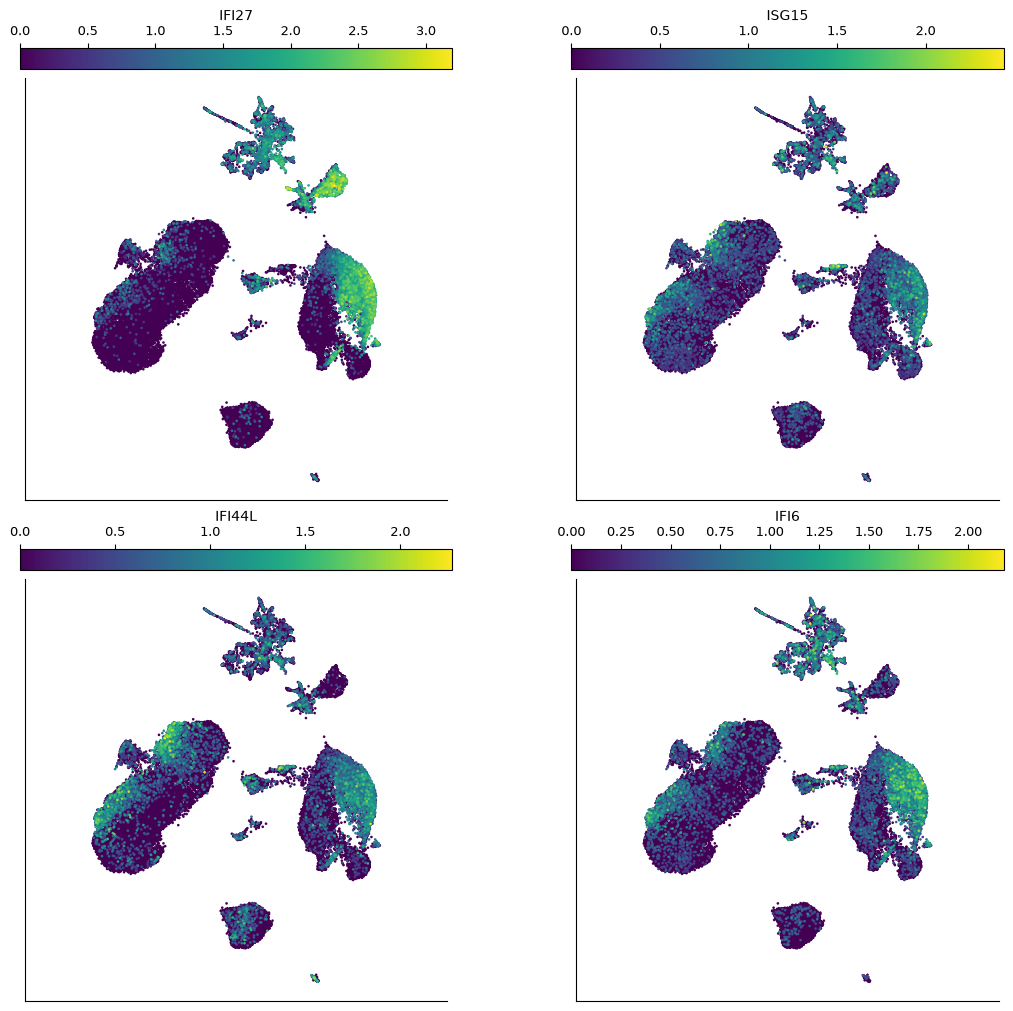

In [14]:
ds.plots.embedding(
    layout=umap_ref,
    color_by=isg_genes,
    normalization=NormalizationSpec(transform="log1p"),
    sort_values=True,
    n_columns=2,
    figsize=(11, 10),
)

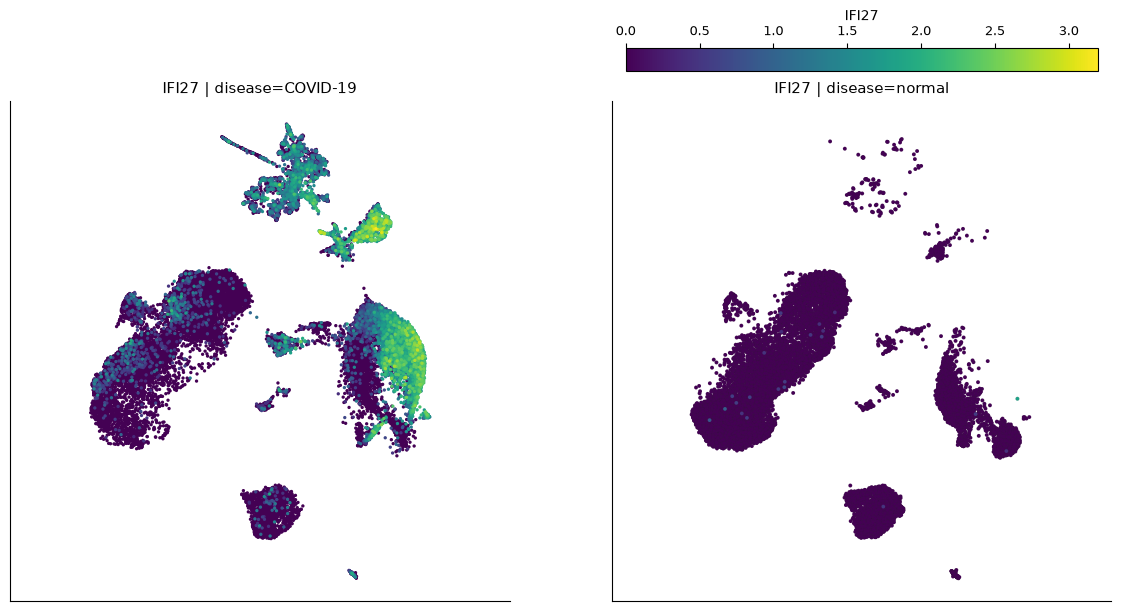

In [15]:
ds.plots.embedding(
    layout=umap_ref,
    color_by=isg_genes[0],
    facet_by="disease",
    normalization=NormalizationSpec(transform="log1p"),
    sort_values=True,
    figsize=(12, 6),
)

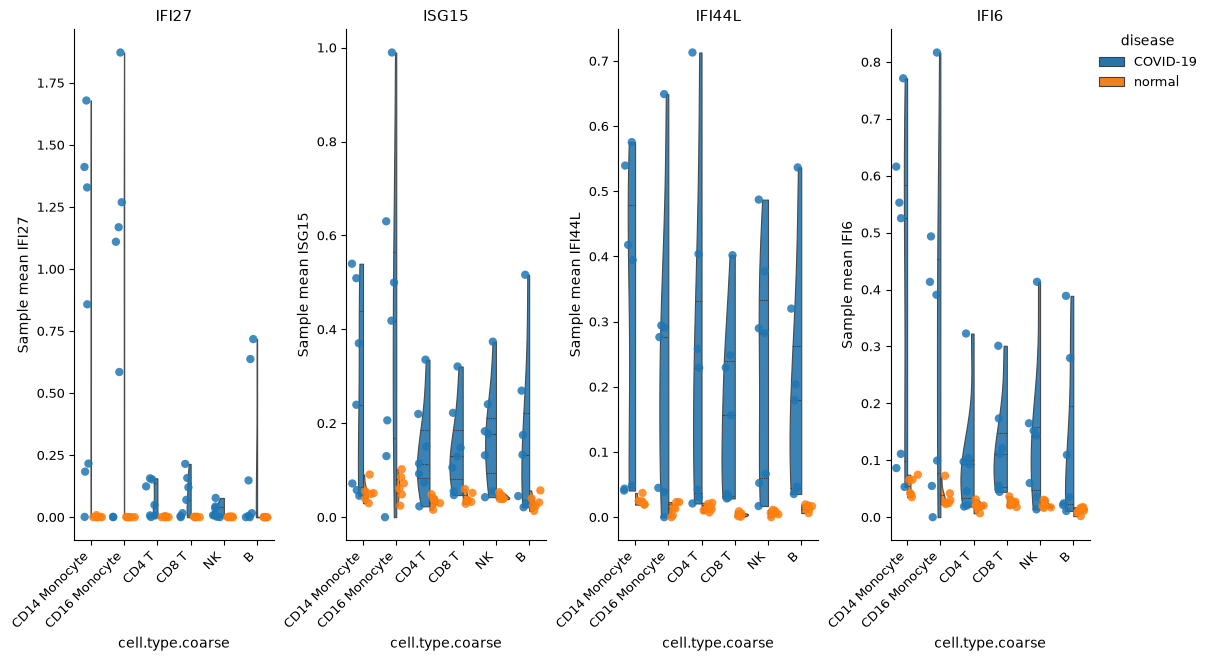

In [16]:
main_types = ["CD14 Monocyte", "CD16 Monocyte", "CD4 T", "CD8 T", "NK", "B"]
ds.plots.distribution(
    isg_genes,
    grouping=CellField("cell.type.coarse"),
    groups=main_types,
    split_by="disease",
    sample_by="donor_id",
    normalization=NormalizationSpec(transform="log1p"),
    share_y=False,
    point_size=6,
    point_alpha=0.85,
    figsize=(12, 6.5),
    max_figure_width=None,
)

In [17]:
expression = pd.DataFrame(
    {
        gene: np.log1p(ds.get_cell_vals(from_assay="RNA", cell_key="I", k=gene))
        for gene in isg_genes
    },
    index=meta.index,
)
expression["ISG mean"] = expression[isg_genes].mean(axis=1)

expression.head()

,IFI27,ISG15,IFI44L,IFI6,ISG mean
ids,,,,,
covid_555_1.1,1.960800,0.000000,0.0,0.0,0.490200
covid_555_1.2,0.000000,0.000000,0.0,0.0,0.000000
covid_555_1.3,1.765848,0.961459,0.0,0.0,0.681827
covid_555_1.7,0.000000,0.000000,0.0,0.0,0.000000
covid_555_1.8,0.926000,0.000000,0.0,0.0,0.231500


In [18]:
monocytes = meta.join(expression).query("`cell.type.coarse` == 'CD14 Monocyte'")
mono_table = monocytes.groupby("donor_id").agg(
    disease=("disease", "first"),
    admission=("Admission", distinct),
    ventilated=("Ventilated", distinct),
    monocytes=("disease", "size"),
    **{column: (column, "mean") for column in [*isg_genes, "ISG mean", "IFN1"]},
)
mono_table.round(3)

,disease,admission,ventilated,monocytes,IFI27,ISG15,IFI44L,IFI6,ISG mean,IFN1
donor_id,,,,,,,,,,
C1,COVID-19,ICU,NonVent / Vent,3419,1.329,0.370,0.395,0.553,0.662,0.149
C2,COVID-19,ICU,NonVent,217,0.216,0.046,0.049,0.111,0.105,0.042
C3,COVID-19,ICU,Vent,1102,0.184,0.072,0.044,0.086,0.096,0.040
C4,COVID-19,ICU,Vent,713,1.411,0.239,0.418,0.525,0.648,0.155
C5,COVID-19,ICU,NonVent,462,1.679,0.540,0.539,0.771,0.882,0.193
C6,COVID-19,ICU,Vent,277,0.858,0.509,0.575,0.616,0.640,0.183
C7,COVID-19,Floor,NonVent,2095,0.001,0.058,0.041,0.053,0.038,0.065
H1,normal,N/A,Healthy,680,0.000,0.030,0.025,0.035,0.022,0.039
H2,normal,N/A,Healthy,325,0.000,0.050,0.019,0.066,0.034,0.044


In [19]:
covid = mono_table.loc[mono_table["disease"] == "COVID-19", "ISG mean"]
healthy = mono_table.loc[mono_table["disease"] == "normal", "ISG mean"]
test = mannwhitneyu(covid, healthy, alternative="two-sided")
rho = spearmanr(mono_table["ISG mean"], mono_table["IFN1"]).statistic

n_above = (covid > healthy.max()).sum()
print(f"Patients above the highest healthy donor: {n_above} of {len(covid)}")
print(
    f"Mann-Whitney U on donor means ({len(covid)} vs {len(healthy)} donors): "
    f"U = {test.statistic:.0f}, two-sided p = {test.pvalue:.4f}"
)
print(
    "Spearman correlation of donor ISG mean with the authors' IFN1 score:",
    f"{rho:.2f}",
)

Patients above the highest healthy donor: 6 of 7
Mann-Whitney U on donor means (7 vs 6 donors): U = 41, two-sided p = 0.0023
Spearman correlation of donor ISG mean with the authors' IFN1 score: 0.73
